In [1]:
import sys
sys.path.append('../../../')

In [2]:
from CADETProcess.simulator import Cadet
process_simulator = Cadet()

In [3]:
process_simulator.check_cadet()

Test simulation completed successfully


True

In [4]:
print(process_simulator.time_resolution)

1.0


In [5]:
print(process_simulator.time_integrator_parameters)

In [6]:
print(process_simulator.solver_parameters)

In [7]:
print(process_simulator.solver_parameters)

In [8]:
from examples.batch_elution.process import process

process.add_parameter_sensitivity('column.total_porosity')

In [9]:
simulation_results = process_simulator.simulate(process)

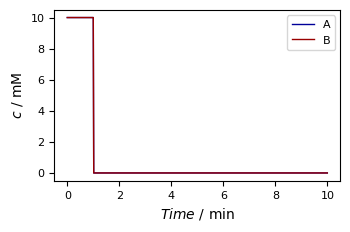

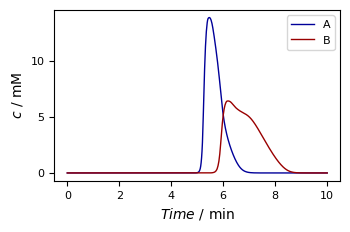

In [10]:
_ = simulation_results.solution.column.inlet.plot()
_ = simulation_results.solution.column.outlet.plot()

In [11]:
_ = simulation_results.solution.column.outlet.plot(components=['A'])

In [12]:
_ = simulation_results.solution.column.outlet.plot(start=5*60, end=9*60)

In [13]:
derivative = simulation_results.solution.column.outlet.derivative
_ = derivative.plot()

In [14]:
print(simulation_results.sensitivity.keys())
print(simulation_results.sensitivity['column.total_porosity'].keys())
print(simulation_results.sensitivity['column.total_porosity'].column.keys())

dict_keys(['column.total_porosity'])
dict_keys(['feed', 'eluent', 'column', 'outlet'])
dict_keys(['inlet', 'outlet'])


In [15]:
_ = simulation_results.sensitivity['column.total_porosity'].column.outlet.plot()

In [16]:
from examples.recycling.mrssr_process import process

C:\Users\ezeiry\Documents\CADET-Process\docs\source\user_guide\../../..\CADETProcess\processModel\unitOperation.py:1498: UserWarning: The field V is only supported for backwards compatibility. Please set initial_liquid_volume and const_solid_volume.
  warnings.warn(


In [17]:
process_simulator.n_cycles = 10
simulation_results = process_simulator.simulate(process)
_ = simulation_results.solution.column.outlet.plot()


In [18]:
from CADETProcess.stationarity import StationarityEvaluator

evaluator = StationarityEvaluator()

In [19]:
from CADETProcess.stationarity import RelativeArea

criterion = RelativeArea()
criterion.threshold = 1e-3

evaluator.add_criterion(criterion)

In [20]:
process_simulator.stationarity_evaluator = evaluator
process_simulator.evaluate_stationarity = True

In [21]:
process_simulator.n_cycles_max = 100

In [22]:
process_simulator.n_cycles_min = 10

In [23]:
simulation_results = process_simulator.simulate(process)
_ = simulation_results.solution.column.outlet.plot()

In [24]:
print(simulation_results.n_cycles)

40


In [25]:
_ = simulation_results.solution_cycles.column.outlet[-1].plot()